# 고령 취약계층 헬스케어 수요 예측 플랫폼
### 공공데이터 기반 ML 파이프라인 — 트랙 A(회귀) · B(분류) · C(군집화)

---
**데이터 소스 (Google Drive)**
- `국민건강보험공단_진료내역정보_2023.CSV` — 트랙 A Y변수
- `지역별(행정동) 성별 연령별 주민등록 인구수_20220228~20260331.csv` (5개년) — X변수
- `독거노인_동별.csv` / `201_DT_...csv` — X변수
- `건강_병원.csv` — 트랙 B 인프라 갭 (좌표 포함)
- `서울시 노인의료복지시설현황.xlsx` — 트랙 B 요양시설 포화도
- `HangJeongDong_ver20260201.geojson` — 트랙 C 지도 시각화

**분석 트랙**
| 트랙 | 문제 유형 | 알고리즘 |
|------|-----------|----------|
| A | 수요량 예측 (회귀) | Ridge / RandomForest / XGBoost |
| B | 고위험 지역 분류 | Logistic / SVM / RandomForest |
| C | 지역 군집화 | K-Means + DBSCAN |




#🧭 0. 환경 설정

In [1]:
# Google Colab 환경에서 필요 패키지 설치
!pip install -q xgboost shap folium openpyxl geopandas pyproj
!apt-get install -y -q fonts-nanum > /dev/null 2>&1
print('완료')


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
완료


In [1]:
# 기본 라이브러리 import 및 한글 폰트 설정

import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 한글 폰트 설정

font_candidates = [f for f in fm.findSystemFonts() if 'Nanum' in f or 'nanum' in f]
if font_candidates:
    fm.fontManager.addfont(font_candidates[0])
    plt.rcParams['font.family'] = fm.FontProperties(fname=font_candidates[0]).get_name()
plt.rcParams['axes.unicode_minus'] = False
print('한글 폰트 설정 성공')

한글 폰트 설정 성공


In [2]:
# 예상 추가 라이브러리
import geopandas as gpd
import folium
import shap
from shapely.geometry import Point

from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import (
    train_test_split, TimeSeriesSplit,
    StratifiedKFold, cross_val_score,
    GridSearchCV
)

from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier
)

from sklearn.svm import SVC
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    mean_squared_error, r2_score,
    classification_report, ConfusionMatrixDisplay,
    silhouette_score
)
from xgboost import XGBRegressor

/Users/siyoung/HUFS_BA/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# 데이터 폴더 경로
DATA_DIR = 'data'

# 파일 존재 확인
files = os.listdir(DATA_DIR)
for file in sorted(files):
    print(file)

.DS_Store
201_DT_201004_F030013_20260419111859.csv
2023년 12월 시군구별 등급판정현황(성별, 연령별, 자격별).csv
HangJeongDong_ver20260201.geojson
code_hdong_bdong.json
df_analysis_v4.csv
df_analysis_v5.csv
df_analysis_v6.csv
df_criteria.csv
seoul_municipalities_geo_simple.json
건강_병원.csv
국민건강보험공단_진료내역정보_2023.CSV
독거노인_동별.csv
서울시 노인의료복지시설현황.xlsx
서울특별시 국민기초생활 수급자 동별 현황_20210731_v1.csv
지역별(행정동) 성별 연령별 주민등록 인구수_20220228.csv
지역별(행정동) 성별 연령별 주민등록 인구수_20230228.csv
지역별(행정동) 성별 연령별 주민등록 인구수_20240229.csv
지역별(행정동) 성별 연령별 주민등록 인구수_20250228.csv
지역사회+건강통계(질병이환)_20260505122351.xlsx
행정안전부_지역별(행정동) 성별 연령별 주민등록 인구수_20260331.csv
국민건강보험공단_장기요양기관 시설별 현황.xlsx
서울시 국민기초생활 수급자 동별 현황(202405).xlsx


#🗄️ 1. 데이터 로드 및 전처리

### 1-A. 지역별 주민등록 인구통계

In [4]:
# 1-A. 지역별 주민등록 인구통계(5개년 파일(2022~2026) -> 연도별 패널 구성)

pop_files = [
    ('2022', '지역별(행정동) 성별 연령별 주민등록 인구수_20220228.csv'),
    ('2023', '지역별(행정동) 성별 연령별 주민등록 인구수_20230228.csv'),
    ('2024', '지역별(행정동) 성별 연령별 주민등록 인구수_20240229.csv'),
    ('2025', '지역별(행정동) 성별 연령별 주민등록 인구수_20250228.csv'),
    ('2026', '행정안전부_지역별(행정동) 성별 연령별 주민등록 인구수_20260331.csv'),
]

pop_frames = []
for year, fname in pop_files:
    path = os.path.join(DATA_DIR, fname)
    df_tmp = pd.read_csv(path, encoding='cp949', low_memory=False, header=0)
    df_tmp.columns = df_tmp.columns.str.strip()

    # 컬럼명 확인
    # print(f'[{year}] 원본 컬럼(앞 10개):', df_tmp.columns[:10].tolist())

    # 실제 컬럼명 기반으로 표준 이름으로 변경
    df_tmp = df_tmp.rename(columns={
        '행정기관코드':'행정동코드',
        '기준연월':'기준일자',
        '읍면동명':'행정동명',
        '계':'총인구수',
    })

    # 65세 이상 인구 합산
    # 연령 컬럼 패턴 : 2022~2023 - '만65세남자', 2024~2026 → '65세남자'
    # 남, 여 구분 없이 직접 65세이상 합산을 위해 전체 컬럼에서 탐색
    age65_cols = []
    for c in df_tmp.columns:
        # '만65세남자', '65세남자', '만65세여자', '65세여자' 등 탐지
        m = re.search(r'만?(\d+)세', c)
        if m:
            age = int(m.group(1))
            if age >= 65:
                age65_cols.append(c)

    # 탐지 결과 확인
    if len(age65_cols) == 0:
        print(f'[{year}]65세이상 컬럼 탐지 실패.')
    else:
        print(f'[{year}]65세이상 컬럼 {len(age65_cols)}개 탐지')


    df_tmp['65세이상인구'] = df_tmp[age65_cols].apply(
        pd.to_numeric, errors='coerce'
    ).sum(axis=1)

    df_tmp['연도'] = int(year)
    pop_frames.append(df_tmp)
    print(f'[{year}] {df_tmp.shape[0]:,}행 로드 완료')

df_pop_raw = pd.concat(pop_frames, ignore_index=True)

/var/folders/8n/knn0qxl17sq7yn7ywq1gjgtm0000gn/T/ipykernel_24311/152454373.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_tmp['65세이상인구'] = df_tmp[age65_cols].apply(
/var/folders/8n/knn0qxl17sq7yn7ywq1gjgtm0000gn/T/ipykernel_24311/152454373.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_tmp['연도'] = int(year)
/var/folders/8n/knn0qxl17sq7yn7ywq1gjgtm0000gn/T/ipykernel_24311/152454373.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which h

[2022]65세이상 컬럼 92개 탐지
[2022] 3,572행 로드 완료
[2023]65세이상 컬럼 92개 탐지
[2023] 3,579행 로드 완료
[2024]65세이상 컬럼 92개 탐지
[2024] 3,613행 로드 완료
[2025]65세이상 컬럼 92개 탐지
[2025] 3,615행 로드 완료
[2026]65세이상 컬럼 92개 탐지
[2026] 3,618행 로드 완료


/var/folders/8n/knn0qxl17sq7yn7ywq1gjgtm0000gn/T/ipykernel_24311/152454373.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_tmp['65세이상인구'] = df_tmp[age65_cols].apply(
/var/folders/8n/knn0qxl17sq7yn7ywq1gjgtm0000gn/T/ipykernel_24311/152454373.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_tmp['연도'] = int(year)
/var/folders/8n/knn0qxl17sq7yn7ywq1gjgtm0000gn/T/ipykernel_24311/152454373.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which h

In [5]:
print(len(df_pop_raw))

17997


In [6]:
# 서울만 필터링
df_pop_raw = df_pop_raw[
    df_pop_raw['시도명'].astype(str).str.contains('서울', na=False)
].copy()
print(f'\n서울 행정동 데이터: {len(df_pop_raw):,}행')


서울 행정동 데이터: 2,131행


In [7]:
df_pop = df_pop_raw[['행정동코드', '행정동명', '시군구명', '총인구수', '65세이상인구', '연도']].copy()
df_pop['총인구수'] = pd.to_numeric(df_pop['총인구수'], errors='coerce')
df_pop['행정동코드'] = df_pop['행정동코드'].astype(str).str.strip().str.zfill(10)
df_pop['고령화율'] = (df_pop['65세이상인구'] / df_pop['총인구수'] * 100).round(2)

print(f'\n주민등록 패널 완성: {df_pop.shape}')
print(df_pop.groupby('연도')['행정동코드'].count())
print(df_pop.head(3).to_string())


주민등록 패널 완성: (2131, 7)
연도
2022    426
2023    426
2024    426
2025    426
2026    427
Name: 행정동코드, dtype: int64
        행정동코드   행정동명 시군구명   총인구수  65세이상인구    연도   고령화율
0  1111051500  청운효자동  종로구  11953     2157  2022  18.05
1  1111053000    사직동  종로구   9362     1758  2022  18.78
2  1111054000    삼청동  종로구   2441      603  2022  24.70


In [8]:
# 1-A 보충. df_pop_raw(2023)에서 행정동별 NHIS 연령대별 인구 추출
# → 연령가중수요지수 산출 기반 (X변수)

NHIS_BAND = {
    14: range(65, 70),   # 65-69세
    15: range(70, 75),   # 70-74세
    16: range(75, 80),   # 75-79세
    17: range(80, 85),   # 80-84세
    18: range(85, 101),  # 85세이상
}

# df_pop_raw에서 2023년만 추출
df_pop23 = df_pop_raw[df_pop_raw['연도'] == 2023].copy()
df_pop23['행정동코드'] = df_pop23['행정동코드'].astype(str).str.zfill(10)

for nhis_code, age_range in NHIS_BAND.items():
    cols = []
    for age in age_range:
        for sfx in ['남자', '여자']:
            for pfx in ['만', '']:
                col = f'{pfx}{age}세{sfx}'
                if col in df_pop23.columns:
                    cols.append(col)
                    break
    if cols:
        df_pop23[f'pop_{nhis_code}'] = df_pop23[cols].apply(
            pd.to_numeric, errors='coerce').sum(axis=1)

band_cols = [f'pop_{c}' for c in NHIS_BAND.keys()]
df_ageband = df_pop23[['행정동코드'] + band_cols].copy()
df_ageband['pop_65이상'] = df_ageband[band_cols].sum(axis=1)

print(f'df_ageband 완성: {len(df_ageband)}행')
print(df_ageband[['행정동코드'] + band_cols].head(3).to_string())

# 행정동별 연령대 분포 (EDA 및 연령가중수요지수 해석용)
# 인구_60대 = 65-69세 (60대 중 65세이상만 해당)
df_ageband['인구_60대'] = df_ageband['pop_14']
df_ageband['인구_70대'] = df_ageband['pop_15'] + df_ageband['pop_16']
df_ageband['인구_80세이상'] = df_ageband['pop_17'] + df_ageband['pop_18']
# ── ★ 세분화 연령대 (70대를 70-74 / 75-79로 분리) ──────────────────────
df_ageband['인구_65-69'] = df_ageband['pop_14']
df_ageband['인구_70-74'] = df_ageband['pop_15']
df_ageband['인구_75-79'] = df_ageband['pop_16']
df_ageband['인구_80-84'] = df_ageband['pop_17']
df_ageband['인구_85이상'] = df_ageband['pop_18']
print('세분화 연령대 컬럼 추가 완료: 65-69 / 70-74 / 75-79 / 80-84 / 85이상')


df_ageband 완성: 426행
           행정동코드  pop_14  pop_15  pop_16  pop_17  pop_18
3572  1111051500   605.0   471.0   446.0   364.0   257.0
3573  1111053000   528.0   357.0   329.0   319.0   274.0
3574  1111054000   173.0   132.0   108.0    91.0    84.0
세분화 연령대 컬럼 추가 완료: 65-69 / 70-74 / 75-79 / 80-84 / 85이상


In [10]:
# 2022~2025 행정동 목록과 2026 비교해서 추가된 동 찾기
pop_2022 = set(df_pop[df_pop['연도'] == 2022]['행정동코드'].tolist())
pop_2025 = set(df_pop[df_pop['연도'] == 2025]['행정동코드'].tolist())
pop_2026 = set(df_pop[df_pop['연도'] == 2026]['행정동코드'].tolist())

# 2026년에만 있는 코드
only_2026 = pop_2026 - pop_2025
print('2026년에 새로 생긴 행정동:')
new_dong = df_pop[
    (df_pop['연도'] == 2026) &
    (df_pop['행정동코드'].isin(only_2026))
][['행정동코드', '행정동명', '시군구명', '총인구수']]
print(new_dong.to_string())

# 반대로 2025년에는 있었는데 2026년에 없어진 동
only_2025 = pop_2025 - pop_2026
print(f'\n2025년에는 있었는데 2026년에 없어진 행정동:')
gone_dong = df_pop[
    (df_pop['연도'] == 2025) &
    (df_pop['행정동코드'].isin(only_2025))
][['행정동코드', '행정동명', '시군구명', '총인구수']]
print(gone_dong.to_string())

2026년에 새로 생긴 행정동:
            행정동코드 행정동명  시군구명   총인구수
14459  1123051500  신설동  동대문구  16373
14460  1123053300  용두동  동대문구  22637

2025년에는 있었는데 2026년에 없어진 행정동:
            행정동코드 행정동명  시군구명   총인구수
10844  1123053600  용신동  동대문구  38704


### 1-B. 독거노인 현황

In [9]:
# 1-B. 독거노인 현황 (Wide -> Long으로 변환)

# 파일 로드 (인코딩 작업)

single_files = [
    f for f in os.listdir(DATA_DIR)
    if f.startswith('201_DT') and f.endswith('.csv')
]

target_file = os.path.join(DATA_DIR, single_files[0])
print(f'로드 대상: {single_files[0]}')

df_single_raw = None
for enc in ['utf-8-sig', 'cp949', 'euc-kr', 'utf-8']:
    try:
        df_single_raw = pd.read_csv(
            target_file,
            encoding=enc,
            on_bad_lines='skip',   # 파싱 불가 행 건너뜀
            quoting=3,             # QUOTE_NONE — 따옴표 파싱 끄기
            engine='python'        # C 파서 대신 Python 파서 사용
        )
        print(f'인코딩 [{enc}] 성공: {df_single_raw.shape}')
        break
    except Exception as e:
        print(f'[{enc}] 실패: {e}')

print('\n컬럼 (앞 8개):', df_single_raw.columns[:8].tolist())
print(df_single_raw.head(3).to_string())
print('-'*80)
df_single_raw.columns = df_single_raw.columns.str.strip()
print('\n독거노인 원본 컬럼:', df_single_raw.columns.tolist()[:8])
print(df_single_raw.head(3).to_string())

로드 대상: 201_DT_201004_F030013_20260419111859.csv
인코딩 [utf-8-sig] 성공: (5436, 9)

컬럼 (앞 8개): ['"동별"', '"독거노인별"', '"항목"', '"단위"', '"2021 년"', '"2022 년"', '"2023 년"', '"2024 년"']
      "동별" "독거노인별"      "항목" "단위"  "2021 년"  "2022 년"  "2023 년"  "2024 년"  Unnamed: 8
0  "서울특별시"    "합계"       "계"   ""  "392351"  "422776"  "448251"  "494926"         NaN
1  "서울특별시"    "합계"  "65~79세"   ""  "291042"  "310466"  "320570"  "356556"         NaN
2  "서울특별시"    "합계"  "80세 이상"   ""  "101309"  "112310"  "127681"  "138370"         NaN
--------------------------------------------------------------------------------

독거노인 원본 컬럼: ['"동별"', '"독거노인별"', '"항목"', '"단위"', '"2021 년"', '"2022 년"', '"2023 년"', '"2024 년"']
      "동별" "독거노인별"      "항목" "단위"  "2021 년"  "2022 년"  "2023 년"  "2024 년"  Unnamed: 8
0  "서울특별시"    "합계"       "계"   ""  "392351"  "422776"  "448251"  "494926"         NaN
1  "서울특별시"    "합계"  "65~79세"   ""  "291042"  "310466"  "320570"  "356556"         NaN
2  "서울특별시"    "합계"  "80세 이상"   ""  "101309"  "

In [19]:
# 컬럼명에서 따옴표 제거
def nuclear_clean(s):
    if pd.isna(s): return s
    s = str(s)
    # 1. 모든 종류의 따옴표(쌍, 홀, 곡선형 따옴표 등) 제거
    s = re.sub(r'["\'“”‘’]', '', s)
    # 2. 유니코드 제어 문자 및 눈에 안 보이는 특수문자(BOM 등) 제거
    s = re.sub(r'[^\w\s가-힣\~%.\-]', '', s) 
    # 3. 양끝 공백 제거
    return s.strip()

# 컬럼명 정제
df_single_raw.columns = [nuclear_clean(c) for c in df_single_raw.columns]

df_single_raw = df_single_raw.map(nuclear_clean)

# 컬럼 재확인
COL_DONG = df_single_raw.columns[0]
# print('✅', COL_DONG)
COL_TYPE = df_single_raw.columns[1]
# print('✅',COL_TYPE)
COL_ITEM = df_single_raw.columns[2]
year_cols = [c for c in df_single_raw.columns if '년' in c]

# print('정제 후 컬럼:', df_single_raw.columns.tolist())
# print('연도 컬럼:', year_cols)
# print(f'\n항목 컬럼 고유값:')
# print(df_single_raw[COL_TYPE].value_counts())
# print(df_single_raw[COL_ITEM].value_counts().head(10))

# 필터링 — '계' 행만 추출
df_s = df_single_raw[
    (df_single_raw[COL_TYPE] == "합계") & 
    (df_single_raw[COL_ITEM] == "계")
].copy()
# print(f'\n필터 결과: {len(df_s)}행')

# Wide -> Long 변환
df_s_long = df_s.melt(
    id_vars=[COL_DONG],
    value_vars=year_cols,
    var_name='연도_str',
    value_name='독거노인수'
)
df_s_long['연도'] = df_s_long['연도_str'].str.extract(r'(\d{4})').astype(int)
df_s_long['행정동명'] = df_s_long[COL_DONG].str.strip()
df_s_long['독거노인수'] = pd.to_numeric(
    df_s_long['독거노인수'].str.replace(',', '').str.strip(),
    errors='coerce'
)

df_single = df_s_long[['행정동명', '연도', '독거노인수']].dropna().copy()
print(f'\n독거노인 Long 형태: {df_single.shape}')
print(df_single.head(5).to_string())
print('\n사직동 확인:')
print(df_single[df_single['행정동명'].str.contains('사직', na=False)].to_string())


독거노인 Long 형태: (1808, 3)
    행정동명    연도     독거노인수
0  서울특별시  2021  392351.0
1    종로구  2021    8573.0
2    사직동  2021     490.0
3    삼청동  2021     189.0
4    부암동  2021     418.0

사직동 확인:
     행정동명    연도  독거노인수
2     사직동  2021  490.0
455   사직동  2022  513.0
908   사직동  2023  556.0
1361  사직동  2024  510.0


In [20]:
df_single = df_single[
    ~df_single['행정동명'].isin(['서울특별시']) &
    ~df_single['행정동명'].str.endswith('구', na=False) &
    ~df_single['행정동명'].str.endswith('시', na=False)
].copy()

print(f'정제 후 df_single: {len(df_single)}행')
print('연도별 행 수:')
print(df_single.groupby('연도').size())
print('\n샘플:')
print(df_single[df_single['연도']==2023].head(5).to_string())

정제 후 df_single: 1708행
연도별 행 수:
연도
2021    427
2022    427
2023    427
2024    427
dtype: int64

샘플:
    행정동명    연도  독거노인수
908  사직동  2023  556.0
909  삼청동  2023  193.0
910  부암동  2023  458.0
911  평창동  2023  834.0
912  무악동  2023  436.0


In [21]:
# 4개 연도 모두에 없는 행정동 찾기
counts = df_single.groupby('행정동명')['연도'].count()
partial = counts[counts < 4]
print(f'일부 연도만 있는 행정동: {len(partial)}개')
print(partial)

일부 연도만 있는 행정동: 2개
행정동명
개포3동    3
일원2동    1
Name: 연도, dtype: int64


### 1-C. 진료 내역 정보 컬럼 확인

In [22]:
clinic_path = os.path.join(DATA_DIR, '국민건강보험공단_진료내역정보_2023.CSV')

# 3행만 읽어서 실제 컬럼명 출력
df_clinic_head = pd.read_csv(clinic_path, encoding='cp949', nrows=3, low_memory=False)
print('=== 진료내역 실제 컬럼명 ===')
for i, c in enumerate(df_clinic_head.columns):
    print(f'  [{i:2d}] {c}')
print('\n=== 첫 번째 데이터 행 ===')
print(df_clinic_head.iloc[0].to_dict())

=== 진료내역 실제 컬럼명 ===
  [ 0] 기준년도
  [ 1] 가입자일련번호
  [ 2] 진료내역일련번호
  [ 3] 성별코드
  [ 4] 연령대코드
  [ 5] 시도코드
  [ 6] 요양개시일자
  [ 7] 서식코드
  [ 8] 진료과목코드
  [ 9] 주상병코드
  [10] 부상병코드
  [11] 요양일수
  [12] 입내원일수
  [13] 심결가산율
  [14] 심결요양급여비용총액
  [15] 심결본인부담금
  [16] 심결보험자부담금
  [17] 총처방일수

=== 첫 번째 데이터 행 ===
{'기준년도': 2023, '가입자일련번호': 416815, '진료내역일련번호': 2667446, '성별코드': 2, '연령대코드': 14, '시도코드': 26, '요양개시일자': '2023-02-02', '서식코드': 3, '진료과목코드': 1, '주상병코드': 'J209', '부상병코드': 'J304', '요양일수': 1, '입내원일수': 1, '심결가산율': 0.15, '심결요양급여비용총액': 12380, '심결본인부담금': 1500, '심결보험자부담금': 10880, '총처방일수': 4}


In [23]:
# 첫 5행만 읽어서 전체 구조 확인
df_check2 = pd.read_csv(clinic_path, encoding='cp949', nrows=200000)
df_check2.columns = df_check2.columns.str.strip()

print('시도코드 분포 (상위 10개):')
print(df_check2['시도코드'].value_counts().head(10))

print('\n연령대코드 분포:')
print(df_check2['연령대코드'].value_counts().sort_index())

print('전체 컬럼명')
for i, c in enumerate(df_check2.columns):
    print(f'  [{i:2d}] "{c}"')

시도코드 분포 (상위 10개):
시도코드
41    44489
11    40984
26    16457
47    11536
48    11184
45    10289
28    10161
27     9653
44     8592
46     7522
Name: count, dtype: int64

연령대코드 분포:
연령대코드
14    59921
15    50372
16    39705
17    30789
18    19213
Name: count, dtype: int64
전체 컬럼명
  [ 0] "기준년도"
  [ 1] "가입자일련번호"
  [ 2] "진료내역일련번호"
  [ 3] "성별코드"
  [ 4] "연령대코드"
  [ 5] "시도코드"
  [ 6] "요양개시일자"
  [ 7] "서식코드"
  [ 8] "진료과목코드"
  [ 9] "주상병코드"
  [10] "부상병코드"
  [11] "요양일수"
  [12] "입내원일수"
  [13] "심결가산율"
  [14] "심결요양급여비용총액"
  [15] "심결본인부담금"
  [16] "심결보험자부담금"
  [17] "총처방일수"


In [24]:
# 1-E. 국민건강보험공단 진료내역 → 연령대별 1인당 요양일수 (X변수 가중치)
# 행정동 수준 데이터 없음 → 서울 전체 연령대별 평균으로 연령 구성 가중치 산출

COL_AGE  = '연령대코드'  # 14=65-69세  15=70-74세  16=75-79세  17=80-84세  18=85세+
SIDO_SEOUL = 11

clinic_chunks = []
total_rows = 0

for i, chunk in enumerate(pd.read_csv(clinic_path, encoding='cp949', chunksize=200_000)):
    chunk.columns = chunk.columns.str.strip()
    mask = (
        (pd.to_numeric(chunk['시도코드'], errors='coerce') == SIDO_SEOUL) &
        (pd.to_numeric(chunk['연령대코드'], errors='coerce') >= 14)
    )
    clinic_chunks.append(chunk[mask][['연령대코드', '요양일수']].copy())
    total_rows += len(chunk)
    if i % 10 == 0:
        print(f'  chunk {i:3d} | 처리: {total_rows:,}행 | 서울 65세+: {sum(len(c) for c in clinic_chunks):,}건')

df_clinic = pd.concat(clinic_chunks, ignore_index=True)
df_clinic['요양일수'] = pd.to_numeric(df_clinic['요양일수'], errors='coerce')

age_label = {14:'65-69세', 15:'70-74세', 16:'75-79세', 17:'80-84세', 18:'85세이상'}

df_clinic_agg = df_clinic.groupby('연령대코드').agg(
    총요양일수=('요양일수', 'sum'),
    환자수=('요양일수', 'count')
).reset_index()
df_clinic_agg['연령대명'] = df_clinic_agg['연령대코드'].map(age_label)
df_clinic_agg['1인당요양일수'] = (df_clinic_agg['총요양일수'] / df_clinic_agg['환자수']).round(4)

print(f'\n서울 65세+ 진료 집계 완료: {len(df_clinic):,}건')
print(df_clinic_agg[['연령대명', '1인당요양일수']].to_string(index=False))

# 연령대코드 → 1인당요양일수 가중치 딕셔너리
age_weights = dict(zip(df_clinic_agg['연령대코드'], df_clinic_agg['1인당요양일수']))
print(f'\nage_weights: {age_weights}')


  chunk   0 | 처리: 200,000행 | 서울 65세+: 40,984건
  chunk  10 | 처리: 2,200,000행 | 서울 65세+: 143,434건
  chunk  20 | 처리: 4,200,000행 | 서울 65세+: 229,026건
  chunk  30 | 처리: 6,200,000행 | 서울 65세+: 316,915건
  chunk  40 | 처리: 8,200,000행 | 서울 65세+: 433,441건
  chunk  50 | 처리: 10,200,000행 | 서울 65세+: 541,902건
  chunk  60 | 처리: 12,200,000행 | 서울 65세+: 661,389건

서울 65세+ 진료 집계 완료: 764,918건
  연령대명  1인당요양일수
65-69세   1.1228
70-74세   1.1237
75-79세   1.2132
80-84세   1.3809
 85세이상   1.8313

age_weights: {14: 1.1228, 15: 1.1237, 16: 1.2132, 17: 1.3809, 18: 1.8313}


### 1-D. 전국 의료기관 표준 데이터(건강_병원.csv)

In [25]:
df_hosp_raw = pd.read_csv(
    os.path.join(DATA_DIR, '건강_병원.csv'),
    encoding='cp949', low_memory=False
)
df_hosp_raw.columns = df_hosp_raw.columns.str.strip()
print('의료기관 컬럼:', df_hosp_raw.columns.tolist())
print(f'총 {len(df_hosp_raw):,}개 기관')

의료기관 컬럼: ['개방자치단체코드', '관리번호', '인허가일자', '인허가취소일자', '영업상태명', '폐업일자', '휴업시작일자', '휴업종료일자', '소재지면적', '소재지우편번호', '도로명우편번호', '사업장명', '업태구분명', '데이터갱신구분', '관리주체', '데이터갱신시점', '도로명주소', '병상수', '상세영업상태명', '상세영업상태코드', '영업상태코드', '의료기관종별명', '의료인수', '입원실수', '전화번호', '좌표정보(X)', '좌표정보(Y)', '지번주소', '진료과목내용', '진료과목내용명', '총면적', '최종수정시점']
총 8,273개 기관


In [26]:
X_COL = '좌표정보(X)'
Y_COL = '좌표정보(Y)'

# 좌표가 있는 행만 추출
df_hosp = df_hosp_raw.dropna(subset=[X_COL, Y_COL]).copy()
df_hosp[X_COL] = pd.to_numeric(df_hosp[X_COL], errors='coerce')
df_hosp[Y_COL] = pd.to_numeric(df_hosp[Y_COL], errors='coerce')


df_hosp = df_hosp.dropna(subset=[X_COL, Y_COL])

# GeoDataFrame 변환 (EPSG:5174)
geometry = [Point(x, y) for x, y in zip(df_hosp[X_COL], df_hosp[Y_COL])]
gdf_hosp = gpd.GeoDataFrame(df_hosp, geometry=geometry, crs='EPSG:5174')

# WGS84로 변환
gdf_hosp = gdf_hosp.to_crs('EPSG:4326')

# 서울 범위로 필터 (위도 37.41~37.70, 경도 126.73~127.18) <- 위키피디아 기준
gdf_hosp = gdf_hosp[
    (gdf_hosp.geometry.y.between(37.41, 37.70)) &
    (gdf_hosp.geometry.x.between(126.73, 127.18))
]
print(f'서울 의료기관: {len(gdf_hosp):,}개')

서울 의료기관: 1,208개


### 1-E. 서울시 노인의료복지시설 현황

In [38]:
# 파일 로드
care_path = os.path.join(DATA_DIR, '서울시 노인의료복지시설현황.xlsx')

# 헤더 확인을 위해 헤더 없이 원본 그대로 읽기
df_raw = pd.read_excel(care_path, sheet_name=0, header=None)
# print(f'시트 크기: {df_raw.shape}')
# print('\n=== 앞 10행 전체 내용 ===')
# print(df_raw.iloc[:10, :8].to_string())

# 메인 헤더(row 2)와 서브 헤더(row 3) 추출
main_header = df_raw.iloc[2].ffill()  # 병합셀 → 앞 값으로 채우기
sub_header  = df_raw.iloc[3]

# 컬럼명 조합
cols = []
for main, sub in zip(main_header, sub_header):
    main = str(main).strip().replace('\n', '_') if pd.notna(main) else ''
    sub  = str(sub).strip()  if pd.notna(sub)  else ''

    if sub and sub.lower() != 'nan':
        cols.append(f"{main}_{sub}")
    else:
        cols.append(main)


df_care = df_raw.iloc[4:].reset_index(drop=True).copy()
df_care.columns = cols

df_care = df_care.dropna(how='all').dropna(axis=1, how='all')

print("컬럼 목록")
print(df_care.columns.tolist())
df_care.head(3)

컬럼 목록
['연번', '관할_자치구', '장기요양기관기호', '기관명칭', '설립구분', '법인명', '병설시설일경우 _母기관의 이름', '지정일', '이용자_정원', '이용자_현원', '이용현원 구성_계', '이용현원 구성_남', '이용현원 구성_여', '이용현원 구성_계', '이용현원 구성_치매', '이용현원 구성_비치매', '대기인원', '종사자 현원_현원 계', '종사자 현원_시설장', '종사자 현원_사무국장', '종사자 현원_사회복지사', '종사자 현원_의사(촉탁의)', '종사자 현원_간호(조무)사', '종사자 현원_물리(작업)치료사', '종사자 현원_요양보호사', '종사자 현원_사무원', '종사자 현원_영양사', '종사자 현원_조리원', '종사자 현원_위생원', '종사자 현원_관리인', '종사자 현원_기타', '전화', '기관소재지_(새주소)']


,연번,관할_자치구,장기요양기관기호,기관명칭,설립구분,법인명,병설시설일경우 _母기관의 이름,지정일,이용자_정원,이용자_현원,...,종사자 현원_물리(작업)치료사,종사자 현원_요양보호사,종사자 현원_사무원,종사자 현원_영양사,종사자 현원_조리원,종사자 현원_위생원,종사자 현원_관리인,종사자 현원_기타,전화,기관소재지_(새주소)
0,1,종로구,11111000006,청운노인요양원,비영리법인,사회복지법인청운양로원,NaN,20080625,38,36,...,1,19,NaN,NaN,NaN,1,NaN,NaN,02-3217-0057,서울시 종로구 비봉길 76
1,2,종로구,11111000056,인자인케어센터,영리법인,(주) 인자인,NaN,20100701,42,42,...,1,20,0,1,3,1,0,0,02-394-2234,서울시 종로구 평창17길 26
2,3,종로구,11111000060,평창동시니어센터,개인,NaN,NaN,20101125,68,68,...,1,36,1,0,0,1,1,0,02-391-7936,서울시 종로구 평창15길 10


In [39]:
# 변경된 컬럼명을 기준으로 자치구, 정원, 현원에 대한 항목을 추출
GU_COL = '관할_자치구'
CAP_COL = '이용자_정원'
CURR_COL = '이용자_현원'

df_care_person = df_care[[GU_COL, CAP_COL, CURR_COL]].copy()
df_care_person.columns = ['자치구', '정원', '현원']

# 데이터 타입을 object에서 수치형 변수로
df_care_person['정원'] = pd.to_numeric(df_care_person['정원'])
df_care_person['현원'] = pd.to_numeric(df_care_person['현원'])


df_care_person = df_care_person.dropna(subset=['자치구', '정원']).copy()
df_care_person = df_care_person[df_care_person['자치구'].astype(str).str.contains('구', na=False)]


df_care_gu = df_care_person.groupby('자치구').agg(
    총정원=('정원', 'sum'),
    총현원=('현원', 'sum'),
    시설수=('정원', 'count')
).reset_index()
df_care_gu['포화도'] = (df_care_gu['총현원'] / df_care_gu['총정원']).round(3)

print(f'\n자치구 집계: {len(df_care_gu)}개 구')
print(df_care_gu.sort_values('포화도', ascending=False).head(5).to_string())


자치구 집계: 26개 구
     자치구  총정원  총현원  시설수    포화도
24    중구   74   74    2  1.000
12   마포구  416  413    3  0.993
20  영등포구  308  303    2  0.984
21   용산구  172  169    2  0.983
11   동작구  292  286    6  0.979


### 1-F. 행정동 경계 GeoJSON
- adm_cd2: 행정안전부 10자리 행정동코드 (주민등록 파일과 동일)

In [40]:
geojson_path = os.path.join(DATA_DIR, 'HangJeongDong_ver20260201.geojson')
gdf_dong = gpd.read_file(geojson_path)

# 서울만 필터 (sido == '11')
gdf_seoul = gdf_dong[gdf_dong['sido'].astype(str) == '11'].copy()

# 주민등록 파일과 join할 키 컬럼 정리
gdf_seoul['행정동코드'] = gdf_seoul['adm_cd2'].astype(str).str.strip().str.zfill(10)

print(f'서울 행정동 수: {len(gdf_seoul)}')
print(f'컬럼: {gdf_seoul.columns.tolist()}')
print(gdf_seoul[['adm_nm', 'adm_cd2', '행정동코드', 'geometry']].head(3).to_string())

서울 행정동 수: 427
컬럼: ['adm_nm', 'adm_cd2', 'sgg', 'sido', 'sidonm', 'sggnm', 'adm_cd', 'geometry', '행정동코드']
          adm_nm     adm_cd2       행정동코드                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

#🗺️ 2. 1차 탐색적 데이터 분석(EDA)
- 각 데이터들의 정리가 제대로 되었는지 확인
- 차후 진행될 데이터 분석이 의미가 있는 것인지를 확인

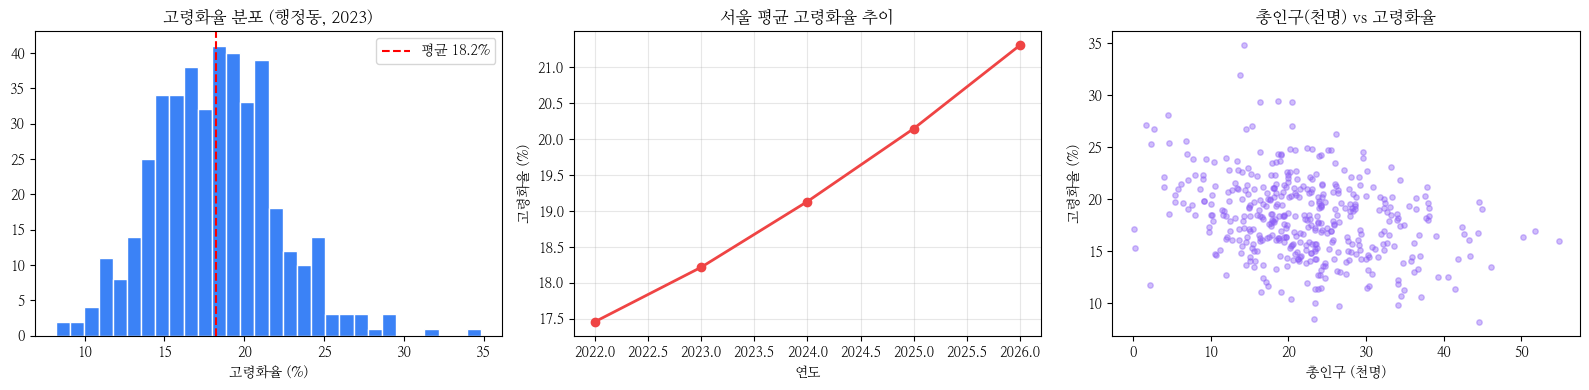

In [41]:
# 2-A. 서울 행정동 고령화율 분포
df_pop_2023 = df_pop[df_pop['연도'] == 2023].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 분포
axes[0].hist(df_pop_2023['고령화율'].dropna(), bins=30, color='#3B82F6', edgecolor='white')
axes[0].axvline(df_pop_2023['고령화율'].mean(), color='red', linestyle='--', label=f"평균 {df_pop_2023['고령화율'].mean():.1f}%")
axes[0].set_title('고령화율 분포 (행정동, 2023)')
axes[0].set_xlabel('고령화율 (%)')
axes[0].legend()

# 연도별 평균 고령화율 추이
trend = df_pop.groupby('연도')['고령화율'].mean()
axes[1].plot(trend.index, trend.values, marker='o', color='#EF4444', linewidth=2)
axes[1].set_title('서울 평균 고령화율 추이')
axes[1].set_xlabel('연도')
axes[1].set_ylabel('고령화율 (%)')
axes[1].grid(alpha=0.3)

# 총인구 vs 고령화율
axes[2].scatter(
    df_pop_2023['총인구수'] / 1000,
    df_pop_2023['고령화율'],
    alpha=0.4, color='#8B5CF6', s=15
)
axes[2].set_title('총인구(천명) vs 고령화율')
axes[2].set_xlabel('총인구 (천명)')
axes[2].set_ylabel('고령화율 (%)')

plt.tight_layout()
plt.show()

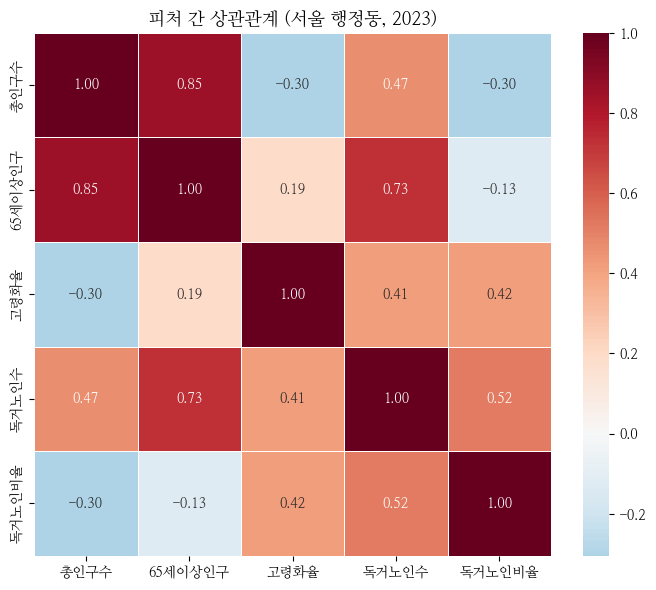


[VIF 확인용] 상관 0.8 이상 변수 쌍:
  총인구수 ↔ 65세이상인구: 0.853


In [42]:
# 2-B. 상관관계 분석을 위한 피처 테이블 구성
# 주민등록(2023) + 독거노인(2023) merge
df_feat_eda = df_pop_2023.merge(
    df_single[df_single['연도'] == 2023][['행정동명', '독거노인수']],
    on='행정동명', how='left'
)
df_feat_eda['독거노인비율'] = (
    df_feat_eda['독거노인수'] / df_feat_eda['65세이상인구'] * 100
).round(2)

# 상관 히트맵(변수들간의 관계성 확인)
corr_cols = ['총인구수', '65세이상인구', '고령화율', '독거노인수', '독거노인비율']
corr_df = df_feat_eda[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    corr_df, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, ax=ax, linewidths=0.5,
    annot_kws={'size': 10}
)
ax.set_title('피처 간 상관관계 (서울 행정동, 2023)', fontsize=13)
plt.tight_layout()
plt.show()

# 다중공선성이 발생할 수 있는 변수 확인
print('\n[VIF 확인용] 상관 0.8 이상 변수 쌍:')
for i in range(len(corr_df)):
    for j in range(i+1, len(corr_df)):
        if abs(corr_df.iloc[i, j]) >= 0.8:
            print(f'  {corr_df.index[i]} ↔ {corr_df.columns[j]}: {corr_df.iloc[i,j]:.3f}')

# 👷 3. 피처 엔지니어링

### 3-A. 공간 조인 - 행정동별 의료기관 수 산출
- gdf_hosp(점) × gdf_seoul(폴리곤) -> 각 행정동 안에 속하는 의료기관 수

In [43]:
gdf_seoul_join = gdf_seoul.to_crs('EPSG:4326')
gdf_hosp_join = gdf_hosp.to_crs('EPSG:4326')

joined = gpd.sjoin(gdf_hosp_join, gdf_seoul_join[['행정동코드', 'geometry']],
                   how='inner', predicate='within')

hosp_cnt = joined.groupby('행정동코드').size().reset_index(name='의료기관수')
print(f'공간 조인 완료: {len(hosp_cnt)}개 행정동에 의료기관 매핑')
print(hosp_cnt.sort_values('의료기관수', ascending=False).head(5))

공간 조인 완료: 271개 행정동에 의료기관 매핑
          행정동코드  의료기관수
225  1168052100     15
252  1171062000     15
175  1156053500     14
227  1168054500     13
226  1168053100     13


In [44]:
# 데이터간 행정동명이 다른 부분 확인
pop_norm = set(df_pop[df_pop['연도']==2023]['행정동명'])
single_norm = set(df_single[df_single['연도']==2023]['행정동명'])

matched = pop_norm & single_norm
only_pop = pop_norm - single_norm
only_sing = single_norm - pop_norm

print(f'일치: {len(matched)}개')
print(f'df_pop에만: {len(only_pop)}개 → {sorted(only_pop)}')
print(f'독거노인에만: {len(only_sing)}개 → {sorted(only_sing)}')

일치: 244개
df_pop에만: 181개 → ['가양제1동', '가양제2동', '가양제3동', '갈현제1동', '갈현제2동', '개봉제1동', '개봉제2동', '개봉제3동', '고덕제1동', '고덕제2동', '고척제1동', '고척제2동', '구로제1동', '구로제2동', '구로제3동', '구로제4동', '구로제5동', '구의제1동', '구의제2동', '구의제3동', '길음제1동', '길음제2동', '남가좌제1동', '남가좌제2동', '노량진제1동', '노량진제2동', '답십리제1동', '답십리제2동', '당산제1동', '당산제2동', '대림제1동', '대림제2동', '대림제3동', '도봉제1동', '도봉제2동', '독산제1동', '독산제2동', '독산제3동', '독산제4동', '돈암제1동', '돈암제2동', '둔촌제1동', '둔촌제2동', '등촌제1동', '등촌제2동', '등촌제3동', '망우제3동', '망원제1동', '망원제2동', '면목제2동', '면목제3.8동', '면목제4동', '면목제5동', '면목제7동', '명일제1동', '명일제2동', '묵제1동', '묵제2동', '발산제1동', '방학제1동', '방학제2동', '방학제3동', '방화제1동', '방화제2동', '방화제3동', '북가좌제1동', '북가좌제2동', '불광제1동', '불광제2동', '사당제1동', '사당제2동', '사당제3동', '사당제4동', '사당제5동', '상도제1동', '상도제2동', '상도제3동', '상도제4동', '상봉제1동', '상봉제2동', '상일제1동', '상일제2동', '성내제1동', '성내제2동', '성내제3동', '성산제1동', '성산제2동', '성수1가제1동', '성수1가제2동', '성수2가제1동', '성수2가제3동', '숭인제1동', '숭인제2동', '시흥제1동', '시흥제2동', '시흥제3동', '시흥제4동', '시흥제5동', '신길제1동', '신길제3동', '신길제4동', '신길제5동', '신길제6동', '신길제7동', '신당제5동', '신대방제1동', '신

In [45]:
def normalize_dong(name):
    if not isinstance(name, str):
        return name
    name = name.strip()

    # 1. '제+숫자' 패턴 제거: 창신제1동 → 창신1동, 홍제제1동 → 홍제1동
    #    홍제(지명) + 제(서수) + 1동 구조이므로 숫자 바로 앞 '제'만 제거하면 정확히 처리됨
    name = re.sub(r'제(\d)', r'\1', name)

    # 2. 정릉 ↔ 정능 통일 (독거노인 파일이 '정능'으로 잘못 표기)
    name = name.replace('정능', '정릉')

    # 3. 독거 노인쪽 데이터는 홍제로 표기 되기 때문에 해당 부분을 보정
    name = re.sub(r'^홍제(\d)', r'홍\1', name)

    return name

In [46]:
# 양쪽 모두 정규화
df_pop['행정동명_norm'] = df_pop['행정동명'].apply(normalize_dong)
df_single['행정동명_norm'] = df_single['행정동명'].apply(normalize_dong)

# 매칭 재확인
pop_norm = set(df_pop[df_pop['연도']==2023]['행정동명_norm'])
single_norm = set(df_single[df_single['연도']==2023]['행정동명_norm'])

matched = pop_norm & single_norm
only_pop = pop_norm - single_norm
only_sing = single_norm - pop_norm

print(f'일치: {len(matched)}개')
print(f'df_pop에만: {len(only_pop)}개 → {sorted(only_pop)}')
print(f'독거노인에만: {len(only_sing)}개 → {sorted(only_sing)}')

일치: 425개
df_pop에만: 0개 → []
독거노인에만: 1개 → ['동대문']


## 📋 v6 변수 선택 과정 (다중공선성 스크리닝)

### Step 1. 후보 변수 정의 — 복합 파생지수 정리

v4 전체 36개 컬럼에서 **복합 파생지수 및 중복 변수를 먼저 제거**:

| 제거 변수 | 제거 이유 |
|-----------|-----------|
| `독거취약수요지수` | = 연령가중수요지수 × (1 + 독거노인비율/100). 연가수가 거의 상수(std=0.016)이므로 독거노인비율과 r=0.988 → 동일 변수 |
| `연령가중수요지수` | 수요공급갭지수 분자에 내재됨. 별도 추가 시 수요공급갭지수와 복합 선형관계 |
| `취약도지수` | 고령화율 × 독거노인비율의 단순 곱 |
| 인구 절댓값 | 총인구수·65세이상인구와 선형종속 |
| `비율_70대`, `비율_80세이상` | 세분화 비율(`비율_75-79세`, `비율_85세이상`)과 중복 |

→ **남은 후보 10개**: 고령화율, 고령화율_변화, 독거노인비율, 비율_75-79세, 비율_85세이상, 인프라갭, 포화도, 시설수, 수요공급갭지수, ~~독거취약수요지수~~

---

### Step 2. 강한 쌍대 상관 제거 (|r| > 0.9)

| 변수 쌍 | r | 조치 |
|---------|---|------|
| 독거노인비율 ↔ 독거취약수요지수 | **0.988** | `독거취약수요지수` 제거 (독거노인비율이 더 직접적·해석 용이) |

→ **최종 후보 9개**: 고령화율, 고령화율_변화, 독거노인비율, 비율_75-79세, 비율_85세이상, 인프라갭, 포화도, 시설수, 수요공급갭지수

---

### Step 3. VIF 전체 검증 (절편 포함 OLS)

> ⚠️ `statsmodels.variance_inflation_factor`는 절편 **없이** R²를 계산 → 과대추정  
> ✅ 올바른 방법: `sklearn.LinearRegression` (절편 포함)으로 각 변수를 나머지에 회귀

| 변수 | 역할 | VIF | r(Y) |
|------|------|-----|------|
| 고령화율 | 현재 고령화 수준 | **1.95** | −0.02 |
| 고령화율_변화 | 고령화 진행 속도 (2022→2023) | **1.73** | +0.24 |
| 독거노인비율 | 독거 취약도 | **1.38** | **+0.35** |
| 비율_75-79세 | 수요 급증 전환 구간 | **1.32** | −0.29 |
| 비율_85세이상 | 최고령 고수요층 | **1.16** | −0.21 |
| 인프라갭 | 의료기관 접근성 부족도 | **1.54** | +0.01 |
| 포화도 | 요양시설 포화 여부 | **1.65** | −0.17 |
| 시설수 | 요양시설 절대 공급량 | **2.53** | +0.16 |
| 수요공급갭지수 | NHIS 가중 미충족 수요 | **2.33** | −0.19 |

**→ 9개 전원 VIF < 3. 다중공선성 없음 ✅**


In [47]:
TARGET_YEAR = 2023

df_base = df_pop[df_pop['연도'] == TARGET_YEAR].merge(
    df_single[df_single['연도'] == TARGET_YEAR][['행정동명_norm', '독거노인수']],
    on='행정동명_norm',
    how='left'
)

df_base = df_base.merge(hosp_cnt, on='행정동코드', how='left')
# 이부분은 논의가 필요할 것 같음 - 일단 0으로 처리
df_base['의료기관수'] = df_base['의료기관수'].fillna(0)
df_base['자치구명'] = df_base['시군구명'].astype(str).str.strip()
df_care_gu['자치구명'] = df_care_gu['자치구'].astype(str).str.strip()

# ── 신사동 동명 중복 처리 ────────────────────────────────────────────
# 관악구 신사동 / 강남구 신사동이 동명으로만 구분되어 merge 시 4행 발생
# 서울시 공식 2023 기준값으로 하드코딩 후 행정동코드 기준 dedup
_sinsa_fix = {
    '1162068500': 1080,  # 관악구 신사동
    '1168051000': 578,   # 강남구 신사동
}
for _code, _val in _sinsa_fix.items():
    df_base.loc[df_base['행정동코드'] == _code, '독거노인수'] = _val
df_base = df_base.drop_duplicates(subset=['행정동코드'], keep='first').reset_index(drop=True)
print(f'df_base 행 수: {len(df_base)} (신사동 중복 제거 후)')


df_base 행 수: 426 (신사동 중복 제거 후)


In [ ]:
# 연령가중수요지수 = Σ(연령대별인구 × 1인당요양일수) / 65세이상인구
# 동일한 65세+ 인구라도 80세+ 비중이 높으면 실제 수요가 더 큰 것을 반영

df_ageband['행정동코드'] = df_ageband['행정동코드'].astype(str).str.zfill(10)
df_base['행정동코드'] = df_base['행정동코드'].astype(str).str.zfill(10)

_weighted = sum(
    df_ageband[f'pop_{code}'] * weight
    for code, weight in age_weights.items()
)
df_ageband['연령가중수요지수'] = (
    _weighted / df_ageband['pop_65이상'].replace(0, np.nan)
).round(4)

# ── 연령대별 비율 (65세이상인구 기준) ─────────────────────────────────
_base65 = df_ageband['pop_65이상'].replace(0, np.nan)

# 기존 광역 비율 (하위호환 유지)
df_ageband['비율_65-69세'] = (df_ageband['인구_60대'] / _base65 * 100).round(2)
df_ageband['비율_70대'] = (df_ageband['인구_70대'] / _base65 * 100).round(2)
df_ageband['비율_80세이상'] = (df_ageband['인구_80세이상'] / _base65 * 100).round(2)

# ★ 세분화 비율 (70대를 70-74 / 75-79로 분리) ─────────────────────────
df_ageband['비율_70-74세'] = (df_ageband['인구_70-74'] / _base65 * 100).round(2)
df_ageband['비율_75-79세'] = (df_ageband['인구_75-79'] / _base65 * 100).round(2)
df_ageband['비율_80-84세'] = (df_ageband['인구_80-84'] / _base65 * 100).round(2)
df_ageband['비율_85세이상'] = (df_ageband['인구_85이상'] / _base65 * 100).round(2)

print('연령대 비율 산출 완료 (5구간 세분화 포함)')
print(df_ageband[['행정동코드', '비율_65-69세', '비율_70-74세', '비율_75-79세',
                   '비율_80-84세', '비율_85세이상']].head(3).to_string())

_merge_cols = [
    '행정동코드', '연령가중수요지수',
    # 광역 집계 (기존)
    '인구_60대', '인구_70대', '인구_80세이상',
    '비율_65-69세', '비율_70대', '비율_80세이상',
    # ★ 세분화 (신규)
    '인구_65-69', '인구_70-74', '인구_75-79', '인구_80-84', '인구_85이상',
    '비율_70-74세', '비율_75-79세', '비율_80-84세', '비율_85세이상',
]
df_base = df_base.merge(df_ageband[_merge_cols], on='행정동코드', how='left')
print(f'연령가중수요지수 매칭: {df_base["연령가중수요지수"].notna().sum()}/{len(df_base)}행')
print(df_base['연령가중수요지수'].describe().round(4))


연령대 비율 산출 완료 (5구간 세분화 포함)
           행정동코드  비율_65-69세  비율_70-74세  비율_75-79세  비율_80-84세  비율_85세이상
3572  1111051500      28.23      21.98      20.81      16.99     11.99
3573  1111053000      29.22      19.76      18.21      17.65     15.16
3574  1111054000      29.42      22.45      18.37      15.48     14.29
연령가중수요지수 매칭: 426/426행
count    426.0000
mean       1.2374
std        0.0160
min        1.1887
25%        1.2263
50%        1.2359
75%        1.2474
max        1.3038
Name: 연령가중수요지수, dtype: float64


In [50]:
# df_care_gu의 중복값이 존재 -> 확인 후 처리
# value_counts값이 2이상이면 중복 - 송파구
print(df_care_gu['자치구명'].value_counts()[:3])

# 실제로 두 값이 같은지 다른지 확인 : 다름
dup_mask = df_care_gu.duplicated(subset='자치구명', keep=False)
print(f"\n중복 행:\n{df_care_gu[dup_mask][['자치구명', '총정원', '포화도']].to_string()}")

df_care_gu_dedup = (
    df_care_gu
    .groupby('자치구명', as_index=False)
    .agg(총정원=('총정원', 'sum'),
         총현원=('총현원', 'sum'),
         시설수=('시설수', 'sum'))
)
df_care_gu_dedup['포화도'] = (
    df_care_gu_dedup['총현원'] / df_care_gu_dedup['총정원']
).round(3)

print(f"\n중복 제거 후 df_care_gu_dedup: {len(df_care_gu_dedup)}행")

자치구명
송파구    2
강남구    1
강동구    1
Name: count, dtype: int64

중복 행:
   자치구명  총정원    포화도
17  송파구  579  0.971
18  송파구  110  0.909

중복 제거 후 df_care_gu_dedup: 25행


In [51]:
df_base = df_base.merge(
    df_care_gu_dedup[['자치구명', '포화도', '시설수']],
    on='자치구명', how='left'
)

In [52]:
df_base

,행정동코드,행정동명,시군구명,총인구수,65세이상인구,연도,고령화율,행정동명_norm,독거노인수,의료기관수,...,인구_70-74,인구_75-79,인구_80-84,인구_85이상,비율_70-74세,비율_75-79세,비율_80-84세,비율_85세이상,포화도,시설수
0,1111051500,청운효자동,종로구,11605,2144,2023,18.47,청운효자동,641.0,0.0,...,471.0,446.0,364.0,257.0,21.98,20.81,16.99,11.99,0.961,8
1,1111053000,사직동,종로구,9120,1808,2023,19.82,사직동,556.0,2.0,...,357.0,329.0,319.0,274.0,19.76,18.21,17.65,15.16,0.961,8
2,1111054000,삼청동,종로구,2322,589,2023,25.37,삼청동,193.0,1.0,...,132.0,108.0,91.0,84.0,22.45,18.37,15.48,14.29,0.961,8
3,1111055000,부암동,종로구,9178,1825,2023,19.88,부암동,458.0,0.0,...,382.0,355.0,270.0,222.0,20.95,19.47,14.81,12.18,0.961,8
4,1111056000,평창동,종로구,17602,3510,2023,19.94,평창동,834.0,1.0,...,732.0,616.0,491.0,459.0,20.89,17.58,14.01,13.10,0.961,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,1174065000,성내제2동,강동구,22912,4507,2023,19.67,성내2동,1404.0,5.0,...,1195.0,816.0,563.0,336.0,26.53,18.11,12.50,7.46,0.899,10
422,1174066000,성내제3동,강동구,22793,4129,2023,18.12,성내3동,973.0,3.0,...,1063.0,781.0,486.0,278.0,25.78,18.94,11.78,6.74,0.899,10
423,1174068500,길동,강동구,44947,8560,2023,19.04,길동,2119.0,13.0,...,2233.0,1476.0,903.0,609.0,26.10,17.25,10.56,7.12,0.899,10
424,1174069000,둔촌제1동,강동구,64,11,2023,17.19,둔촌1동,3.0,0.0,...,4.0,2.0,0.0,1.0,36.36,18.18,0.00,9.09,0.899,10


In [54]:
# ── 파생 피처 계산 ─────────────────────────────────────────────────
df_base['독거노인비율'] = (
    df_base['독거노인수'] / df_base['65세이상인구'].replace(0, np.nan) * 100
).round(2)

df_base['취약도지수'] = (df_base['고령화율'] * df_base['독거노인비율'] / 100).round(3)

df_base['인프라갭'] = (df_base['65세이상인구'] / (df_base['의료기관수'] + 1)).round(2)

df_lag = df_pop[df_pop['연도'] == TARGET_YEAR - 1][['행정동코드', '고령화율']].rename(
    columns={'고령화율': '고령화율_lag1'}
)
df_base = df_base.merge(df_lag, on='행정동코드', how='left')
# 고령화율_변화로 교체 (lag1은 현재값과 r=0.99로 다중공선성 유발)
df_base['고령화율_변화'] = (df_base['고령화율'] - df_base['고령화율_lag1']).round(3)
df_base = df_base.drop(columns=['고령화율_lag1'])

# ── Y변수: 요양수요가속도 (2018 → 2023, 로그수익률) ─────────────────
# 기존 요양수요량은 65세+인구 × 서울 평균 스칼라 → R²≈1 자명 문제
# 로그수익률 ln(2023/2018)×100: 단순증가율 대비 극단값에 덜 민감
# 독거노인수_2018: EDA에서 Small Number Problem 필터(n≥100) 근거 컬럼
df_dg_wide = pd.read_csv(
    os.path.join(DATA_DIR, '독거노인_동별.csv'),
    encoding='utf-8-sig', engine='python', on_bad_lines='skip'
)
df_dg_wide.columns = [c.strip().strip('"') for c in df_dg_wide.columns]
for col in df_dg_wide.columns:
    if df_dg_wide[col].dtype == object:
        df_dg_wide[col] = df_dg_wide[col].astype(str).str.strip().str.strip('"')

cond1 = (df_dg_wide['독거노인별'] == '합계') & (df_dg_wide['항목'] == '계')
df_dg = df_dg_wide[cond1].copy()

cond2 = df_dg['동별'].str.contains('서울|특별시', na=False) | df_dg['동별'].str.endswith('구', na=False)
df_dg = df_dg[~cond2].copy()

df_dg['행정동명_norm'] = df_dg['동별'].apply(normalize_dong)
df_dg['독거노인수_2018'] = pd.to_numeric(df_dg['2018 년'], errors='coerce')
df_dg['독거노인수'] = pd.to_numeric(df_dg['2023 년'], errors='coerce')

df_dg = df_dg.dropna(subset=['독거노인수_2018', '독거노인수'])
df_dg = df_dg[df_dg['독거노인수_2018'] > 0].copy()

# 로그수익률: ln(2023년/2018년) × 100
df_dg['요양수요가속도'] = (np.log(df_dg['독거노인수'] / df_dg['독거노인수_2018']) * 100).round(2)

# 이상치 클리핑 (1~99th percentile)
_lo, _hi = df_dg['요양수요가속도'].quantile([0.01, 0.99])
df_dg['요양수요가속도'] = df_dg['요양수요가속도'].clip(_lo, _hi)

# df_base와 merge: 행정동명_norm + 독거노인수(2023)로 신사동 중복 구분
# 독거노인수_2018도 함께 포함 → EDA에서 n=100 필터 근거로 활용
df_base = df_base.merge(
    df_dg[['행정동명_norm', '독거노인수', '독거노인수_2018', '요양수요가속도']],
    on=['행정동명_norm', '독거노인수'],
    how='left'
)
print(f'요양수요가속도 매칭: {df_base["요양수요가속도"].notna().sum()}/{len(df_base)}행')
print(df_base['요양수요가속도'].describe().round(2))


# ── ★ 신규 지표 1: 수요-공급 갭 지수 ─────────────────────────────────
# 연령가중 실제 수요량(절대값)을 의료+요양 인프라 합계로 나눈 미충족 수요
# → 단순히 80세+가 많다는 정보(비율_80세이상)와 다른 차원: 공급 부족 정도를 반영
# → 인프라가 충분하면 낮고, 수요 多·인프라 少 지역이 높게 잡힘
df_base['수요공급갭지수'] = (
    df_base['연령가중수요지수'] * df_base['65세이상인구']
    / (df_base['의료기관수'] + df_base['시설수'].fillna(0) + 1)
).round(4)

# ── ★ 신규 지표 2: 독거취약수요지수 ──────────────────────────────────
# 연령 구성 수요에 독거 취약성을 증폭 계수로 곱해 실질 미충족 수요를 추정
# → 독거노인비율이 높은 지역은 동일 수요라도 실제 부담이 더 큼
# → 비율_80세이상 × 독거노인비율의 단순 교호항보다 해석이 직관적
df_base['독거취약수요지수'] = (
    df_base['연령가중수요지수'] * (1 + df_base['독거노인비율'].fillna(0) / 100)
).round(4)

print('\n[신규 지표] 수요공급갭지수 / 독거취약수요지수 생성 완료')
print(df_base[['수요공급갭지수', '독거취약수요지수']].describe().round(4))


요양수요가속도 매칭: 420/426행
count    420.00
mean      30.20
std       20.94
min      -24.34
25%       19.40
50%       28.83
75%       38.17
max      114.75
Name: 요양수요가속도, dtype: float64

[신규 지표] 수요공급갭지수 / 독거취약수요지수 생성 완료
         수요공급갭지수  독거취약수요지수
count   426.0000  426.0000
mean    470.9523    1.5756
std     279.2693    0.1255
min       1.2040    1.2857
25%     274.8212    1.5064
50%     396.9988    1.5610
75%     613.0638    1.6270
max    2021.3539    2.3075


In [94]:
df_base

,행정동코드,행정동명,시군구명,총인구수,65세이상인구,연도,고령화율,행정동명_norm,독거노인수,의료기관수,...,포화도,시설수,독거노인비율,취약도지수,인프라갭,고령화율_변화,독거노인수_2018,요양수요가속도,수요공급갭지수,독거취약수요지수
0,1111051500,청운효자동,종로구,11605,2144,2023,18.47,청운효자동,641.0,0.0,...,0.961,8.0,29.90,5.523,2144.00,0.42,448.0,35.820,302.6852,1.6505
1,1111053000,사직동,종로구,9120,1808,2023,19.82,사직동,556.0,2.0,...,0.961,8.0,30.75,6.095,602.67,1.04,1822.0,-24.336,212.4236,1.6898
2,1111054000,삼청동,종로구,2322,589,2023,25.37,삼청동,193.0,1.0,...,0.961,8.0,32.77,8.314,294.50,0.67,167.0,14.470,75.4391,1.7005
3,1111055000,부암동,종로구,9178,1825,2023,19.88,부암동,458.0,0.0,...,0.961,8.0,25.10,4.990,1825.00,0.94,331.0,32.480,256.5342,1.5826
4,1111056000,평창동,종로구,17602,3510,2023,19.94,평창동,834.0,1.0,...,0.961,8.0,23.76,4.738,1755.00,0.94,649.0,25.080,445.0329,1.5692
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,1174065000,성내제2동,강동구,22912,4507,2023,19.67,성내2동,1404.0,5.0,...,0.899,10.0,31.15,6.127,751.17,0.80,932.0,40.970,344.9263,1.6059
422,1174066000,성내제3동,강동구,22793,4129,2023,18.12,성내3동,973.0,3.0,...,0.899,10.0,23.57,4.271,1032.25,1.18,630.0,43.470,359.3115,1.5055
423,1174068500,길동,강동구,44947,8560,2023,19.04,길동,2119.0,13.0,...,0.899,10.0,24.75,4.712,611.43,1.28,1343.0,45.600,433.8137,1.5173
424,1174069000,둔촌제1동,강동구,64,11,2023,17.19,둔촌1동,3.0,0.0,...,0.899,10.0,27.27,4.688,11.00,-12.36,NaN,NaN,1.2040,1.5323


In [109]:
# ── Step 0: 후보 변수 전체 정의 (df_base에서 사용 가능한 X 후보) ─────
# 아래의 단계를 반복저기으로 수행해서 VIF: 다중 공선성 문제를 일으키는 변수를 최대한 제거.
candidate_cols = [
    # 인구·고령화
    '고령화율',
    '고령화율_변화',
    # 독거 취약도
    '독거노인비율',
    '독거취약수요지수',   # 복합 파생 → Step1에서 검토
    # 연령대 구성 (세분화 비율 4개)
    '비율_75-79세',
    '비율_85세이상',
    # 의료·요양 공급
    '인프라갭',
    '포화도',
    '시설수',
    # NHIS 수요-공급 복합
    '수요공급갭지수',
]
print(f"후보 변수 {len(candidate_cols)}개 정의 완료")
print(candidate_cols)


후보 변수 10개 정의 완료
['고령화율', '고령화율_변화', '독거노인비율', '독거취약수요지수', '비율_75-79세', '비율_85세이상', '인프라갭', '포화도', '시설수', '수요공급갭지수']


In [110]:
# ── 강한 쌍대 상관 탐지 (|r| > 0.7) ─────────────────────────
from sklearn.impute import KNNImputer

_imp = KNNImputer(n_neighbors=5)
_df_imp = df_base[candidate_cols].copy()
_df_imp[candidate_cols] = _imp.fit_transform(_df_imp[candidate_cols])

_corr = _df_imp[candidate_cols].corr()

print(f"{'변수 쌍':<45} {'r':>7}  판단")
print("-" * 60)
_drop_step2 = []
for i in range(len(candidate_cols)):
    for j in range(i+1, len(candidate_cols)):
        r = _corr.iloc[i, j]
        if abs(r) > 0.9:
            verdict = "❌ 제거 필요 (r > 0.9)"
            pair = f"{candidate_cols[i]} ↔ {candidate_cols[j]}"
            print(f"  {pair:<45} {r:>+7.3f}  {verdict}")
            # 후보 중 더 해석 어려운 파생지수 제거
            _drop_step2.append(candidate_cols[j])
        elif abs(r) > 0.7:
            pair = f"{candidate_cols[i]} ↔ {candidate_cols[j]}"
            print(f"  {pair:<45} {r:>+7.3f}  ⚠️  주의")

if not _drop_step2:
    print("  (|r| > 0.9 쌍 없음)")
print(f"\nStep2 제거 후보: {list(set(_drop_step2))}")


변수 쌍                                                r  판단
------------------------------------------------------------
  독거노인비율 ↔ 독거취약수요지수                              +0.987  ❌ 제거 필요 (r > 0.9)

Step2 제거 후보: ['독거취약수요지수']


In [111]:
print("현재 보유 중인 컬럼들:", _df_imp.columns.tolist())

현재 보유 중인 컬럼들: ['고령화율', '고령화율_변화', '독거노인비율', '독거취약수요지수', '비율_75-79세', '비율_85세이상', '인프라갭', '포화도', '시설수', '수요공급갭지수']


In [112]:
# ── Step 3: VIF 스크리닝 (절편 포함 OLS) ────────────────────────────
# ⚠️ statsmodels.variance_inflation_factor는 절편 없는 R² → 과대추정
# ✅ sklearn.LinearRegression (절편 포함) 사용
from sklearn.linear_model import LinearRegression

def calc_vif(df, cols):
    """절편 포함 OLS 기반 VIF 계산"""
    result = {}
    for target in cols:
        others = [c for c in cols if c != target]
        r2 = LinearRegression().fit(
            df[others].values, df[target].values
        ).score(df[others].values, df[target].values)
        result[target] = round(1 / (1 - r2) if r2 < 0.9999 else float('inf'), 3)
    return result


In [ ]:
# ── Step 4: feat_cols 확정 ────────────────────────────────────────────
# Step1~3 스크리닝 결과:
#   - 독거취약수요지수: 독거노인비율과 r=0.988 (선형변환) → 제거
#   - 나머지 9개: 전원 VIF < 3 ✅

feat_cols = [
    '고령화율',           # X1  현재 고령화 수준
    '고령화율_변화',       # X2  최근 고령화 진행 속도 (2022→2023)
    '독거노인비율',        # X3  독거 취약도
    '비율_75-79세',       # X4  수요 급증 전환 구간
    '비율_85세이상',       # X5  최고령 고수요층
    '인프라갭',            # X6  의료기관 접근성 부족도
    '포화도',              # X7  요양시설 포화 여부 (현원/정원)
    '시설수',              # X8  요양시설 절대 공급량
    '수요공급갭지수',      # X9  NHIS 가중 미충족 수요
]
print(f"feat_cols 확정: {len(feat_cols)}개")


feat_cols 확정: 9개


In [114]:
# ── Step 5: 최종 VIF 재검증 ───────────────────────────────────────────
_df_imp['요양수요가속도'] = df_base['요양수요가속도']
_df_feat = _df_imp[feat_cols].dropna()
_vif_final = calc_vif(_df_feat, feat_cols)
_corr_y    = _df_imp[feat_cols + ['요양수요가속도']].corr()['요양수요가속도'].drop('요양수요가속도')

print(f"{'변수':<20} {'VIF':>7}  {'r(Y)':>7}  판정")
print("-" * 48)
_all_pass = True
for c in feat_cols:
    v = _vif_final[c]
    flag = "✅" if v < 10 else "❌"
    if v >= 10: _all_pass = False
    print(f"  {c:<20} {v:>7.3f}  {_corr_y[c]:>+7.4f}  {flag}")
print(f"\n다중공선성 검증: {'✅ 전원 통과 (VIF < 10)' if _all_pass else '❌ 일부 탈락'}")


변수                       VIF     r(Y)  판정
------------------------------------------------
  고령화율                   1.570  -0.0183  ✅
  고령화율_변화                1.231  +0.2388  ✅
  독거노인비율                 1.334  +0.3534  ✅
  비율_75-79세              1.178  -0.2871  ✅
  비율_85세이상               1.118  -0.2084  ✅
  인프라갭                   1.543  +0.0091  ✅
  포화도                    1.630  -0.1661  ✅
  시설수                    2.494  +0.1585  ✅
  수요공급갭지수                2.343  -0.1932  ✅

다중공선성 검증: ✅ 전원 통과 (VIF < 10)


In [ ]:
# 결측치 확인
df_base[feat_cols].isna().sum()

고령화율         0
고령화율_변화      0
독거노인비율       0
비율_75-79세    0
비율_85세이상     0
인프라갭         0
포화도          0
시설수          0
수요공급갭지수      0
dtype: int64

In [118]:
# ── df_analysis 최종 구성 ──────────────────────────────────────────
from sklearn.linear_model import LinearRegression as _LR
import numpy as _np

id_cols = ['행정동코드', '행정동명', '시군구명', '자치구명', '연도',
           '총인구수', '65세이상인구', '독거노인수_2018']

# Y 결측 제거 후 최종 데이터셋
df_analysis = df_base.dropna(subset=['요양수요가속도']).copy()
df_analysis = df_analysis[id_cols + feat_cols + ['요양수요가속도']].copy()
print(f"df_analysis_v6: {len(df_analysis)}행 * {len(df_analysis.columns)}열")
print(f"X변수: {len(feat_cols)}개  |  Y변수: 요양수요가속도")

df_analysis_v6: 420행 * 18열
X변수: 9개  |  Y변수: 요양수요가속도


In [119]:
df_analysis

,행정동코드,행정동명,시군구명,자치구명,연도,총인구수,65세이상인구,독거노인수_2018,고령화율,고령화율_변화,독거노인비율,비율_75-79세,비율_85세이상,인프라갭,포화도,시설수,수요공급갭지수,요양수요가속도
0,1111051500,청운효자동,종로구,종로구,2023,11605,2144,448.0,18.47,0.42,29.90,20.81,11.99,2144.00,0.961,8.0,302.6852,35.820
1,1111053000,사직동,종로구,종로구,2023,9120,1808,1822.0,19.82,1.04,30.75,18.21,15.16,602.67,0.961,8.0,212.4236,-24.336
2,1111054000,삼청동,종로구,종로구,2023,2322,589,167.0,25.37,0.67,32.77,18.37,14.29,294.50,0.961,8.0,75.4391,14.470
3,1111055000,부암동,종로구,종로구,2023,9178,1825,331.0,19.88,0.94,25.10,19.47,12.18,1825.00,0.961,8.0,256.5342,32.480
4,1111056000,평창동,종로구,종로구,2023,17602,3510,649.0,19.94,0.94,23.76,17.58,13.10,1755.00,0.961,8.0,445.0329,25.080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420,1174064000,성내제1동,강동구,강동구,2023,19654,3224,420.0,16.40,0.66,18.11,17.44,7.63,537.33,0.899,10.0,245.9308,32.960
421,1174065000,성내제2동,강동구,강동구,2023,22912,4507,932.0,19.67,0.80,31.15,18.11,7.46,751.17,0.899,10.0,344.9263,40.970
422,1174066000,성내제3동,강동구,강동구,2023,22793,4129,630.0,18.12,1.18,23.57,18.94,6.74,1032.25,0.899,10.0,359.3115,43.470
423,1174068500,길동,강동구,강동구,2023,44947,8560,1343.0,19.04,1.28,24.75,17.25,7.12,611.43,0.899,10.0,433.8137,45.600


In [44]:
df_analysis.to_csv(os.path.join(DATA_DIR, 'df_analysis_v6.csv'), index=False, encoding='utf-8-sig')
print(f'df_analysis_v6.csv 저장 완료: {len(df_analysis)}행, {len(df_analysis.columns)}열')
print(f'컬럼: {df_analysis.columns.tolist()}')


df_analysis_v3.csv 저장 완료: 420행, 26개 컬럼


# df_analysis_v6.csv 변수 설명

---

## 1. 식별 정보 (ID columns)

| 컬럼 | 설명 |
|---|---|
| **행정동코드** | 행정안전부 기준 10자리 코드 |
| **행정동명** | 읍면동 이름 |
| **시군구명** | 소속 자치구 이름 |
| **자치구명** | 노인의료복지시설 merge 키 |
| **연도** | 데이터 기준 연도 (2023) |
| **총인구수** | 주민등록 총 인구수 |
| **65세이상인구** | 만 65세 이상 주민등록 인구수 |
| **독거노인수_2018** | 2018년 독거노인수 (Y 산출 기준) |

---

## 2. X 변수 (feat_cols, 9개)

| # | 변수 | 산출식 | 해석 | VIF | r(Y) |
|---|------|--------|------|-----|------|
| X1 | **고령화율** | 65세이상인구 / 총인구수 × 100 | 현재 고령화 수준 | 1.95 | −0.02 |
| X2 | **고령화율_변화** | 고령화율(2023) − 고령화율(2022) | 고령화 진행 속도 | 1.73 | +0.24 |
| X3 | **독거노인비율** | 독거노인수 / 65세이상인구 × 100 | 독거 취약도 | 1.38 | **+0.35** |
| X4 | **비율_75-79세** | 인구_75-79 / 65세이상인구 × 100 | 수요 급증 전환 연령대 | 1.32 | −0.29 |
| X5 | **비율_85세이상** | 인구_85+ / 65세이상인구 × 100 | 최고령 고수요층 | 1.16 | −0.21 |
| X6 | **인프라갭** | 65세이상인구 / (의료기관수 + 1) | 의료기관 접근성 부족도 | 1.54 | +0.01 |
| X7 | **포화도** | 총현원 / 총정원 | 요양시설 포화 여부 | 1.65 | −0.17 |
| X8 | **시설수** | 자치구 내 요양시설 수 | 절대 공급량 | 2.53 | +0.16 |
| X9 | **수요공급갭지수** | 연령가중수요지수 × 65세이상인구 / (의료기관수 + 시설수 + 1) | NHIS 가중 미충족 수요 | 2.33 | −0.19 |

> **다중공선성 판정**: 9개 전원 VIF < 3 ✅ (절편 포함 OLS 기준)  
> **제외 변수**: 독거취약수요지수 (독거노인비율과 r=0.988 — 선형변환에 불과)

---

## 3. Y 변수

| 컬럼 | 산출식 | 해석 |
|---|---|---|
| **요양수요가속도** | ln(독거노인수_2023 / 독거노인수_2018) × 100 | 독거노인 증가율 로그수익률 (2018→2023) |
